Vehicle Damage Detection using YOLOv8

**Author:**
Praveen

**Project:**
AI-powered Vehicle Damage Assessment and Repair Cost Estimation

**Objective:**
Detect damaged regions in vehicle images using YOLOv8 as the first stage of an end-to-end insurance claim automation system.

# **Step 0 - Configuration**

In [ ]:
# ==========================
# Project Configuration
# ==========================

CONFIG = {
    "model": "yolov8n.pt",
    "imgsz": 640,
    "epochs": 50,
    "batch": 16,
    "workers": 2,
    "project": "vehicle_damage_yolo",
    "experiment": "yolov8n_v1",
    "seed": 42,
}

In [ ]:
# # ==========================
# # Project Configuration
# # ==========================

# CONFIG = {
#     "model": "yolov8n.pt",
#     "imgsz": 640,
#     "epochs": 100,
#     "patience": 15,
#     "batch": 16,
#     "workers": 2,
#     "seed": 42,
#     "project": "vehicle_damage_yolo",
#     "experiment": "vehicle_damage_yolov8n",
# }

# **Step 1 — Environment Setup**

In [ ]:
!pip install -q ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 116.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.9 MB/s eta 0:00:00


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=Warning, lineno=0, append=False)

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# **Step 2 — GPU Check**

In [ ]:
import torch

print("Torch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch Version: 2.11.0+cu128
CUDA Available: True
GPU: Tesla T4


# **Step 3 — Download Dataset**

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="rwbqRpCKjLHFdvbq5dr3")
project = rf.workspace("capstone-nh0nc").project("car-damage-detection-t0g92")
version = project.version(3)
dataset = version.download("yolov8")
DATASET_PATH = dataset.location

print(DATASET_PATH)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Car-Damage-Detection-3 in yolov8:: 100%|██████████| 10570/10570 [00:02<00:00, 4581.60it/s]

/content/Car-Damage-Detection-3


# **Step 4 — Dataset Inspection**

In [ ]:
import os

# Dataset path
DATASET_PATH = dataset.location

print("=" * 60)
print("Dataset Path:", DATASET_PATH)
print("=" * 60)

# Show folder structure
for folder in os.listdir(DATASET_PATH):
    print(folder)

Dataset Path: /content/Car-Damage-Detection-3
test
README.dataset.txt
README.roboflow.txt
data.yaml
valid
train


In [ ]:
# Check train/valid/test folders

splits = ["train", "valid", "test"]

for split in splits:
    image_dir = os.path.join(DATASET_PATH, split, "images")
    label_dir = os.path.join(DATASET_PATH, split, "labels")

    num_images = len(os.listdir(image_dir))
    num_labels = len(os.listdir(label_dir))

    print(f"{split.upper()}")
    print(f"Images : {num_images}")
    print(f"Labels : {num_labels}")
    print("-" * 30)

TRAIN
Images : 4568
Labels : 4568
------------------------------
VALID
Images : 657
Labels : 657
------------------------------
TEST
Images : 54
Labels : 54
------------------------------


In [ ]:
import yaml

yaml_path = os.path.join(DATASET_PATH, "data.yaml")

with open(yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

print(data_yaml)

{'names': ['Bonnet', 'Bumper', 'Dickey', 'Door', 'Fender', 'Light', 'Windshield'], 'nc': 7, 'roboflow': {'license': 'CC BY 4.0', 'project': 'car-damage-detection-t0g92', 'url': 'https://universe.roboflow.com/capstone-nh0nc/car-damage-detection-t0g92/dataset/3', 'version': 3, 'workspace': 'capstone-nh0nc'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}


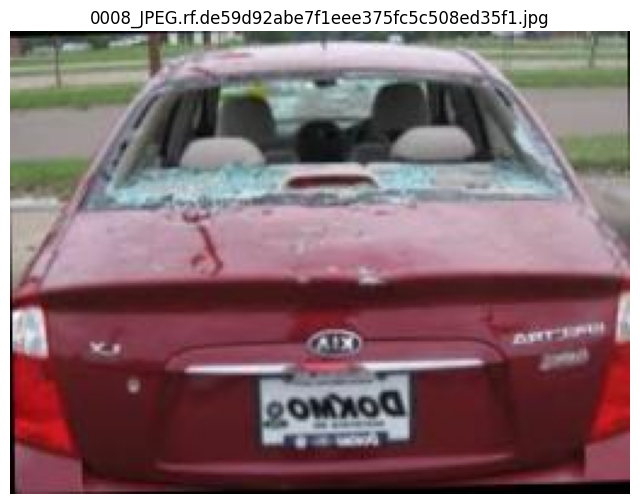

Label File:
6 0.2200125234375 0.10663467539267016 0.11766684375 0.37983705759162306 0.41432662109375 0.3727075340314136 0.92394414453125 0.3691079371727749 0.78773019140625 0.08848848691099477 0.39064740625 0.07927275392670156 0.2200125234375 0.10663467539267016


In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics.utils.plotting import Annotator
import os

# Pick a random training image
image_dir = os.path.join(DATASET_PATH, "train", "images")
label_dir = os.path.join(DATASET_PATH, "train", "labels")

image_name = random.choice(os.listdir(image_dir))

image_path = os.path.join(image_dir, image_name)
label_path = os.path.join(label_dir, image_name.replace(".jpg", ".txt").replace(".png", ".txt").replace(".jpeg", ".txt"))

img = Image.open(image_path)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.title(image_name)
plt.axis("off")
plt.show()

print("Label File:")
with open(label_path, "r") as f:
    print(f.read())

In [ ]:
# from ultralytics import YOLO

# # Load pretrained YOLO just for visualization
# model = YOLO("yolov8n.pt")

# results = model.predict(
#     source=image_path,
#     conf=0.1,
#     show=False
# )

# annotated = results[0].plot()

# plt.figure(figsize=(8,8))
# plt.imshow(annotated[:,:,::-1])
# plt.axis("off")
# plt.show()

# **Step 5 — Mount Google Drive**

In [ ]:
#check model
model = YOLO(CONFIG["model"])

print(model)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/Vehicle_Damage_Project"

print(SAVE_DIR)

/content/drive/MyDrive/Vehicle_Damage_Project


# **Step 6 — Smoke Test (5 Epochs)**

In [ ]:
# ======================================================
# Smoke Test Training (5 Epochs)
# ======================================================

# Create a fresh YOLO model
model = YOLO(CONFIG["model"])

# Train
results = model.train(
    data=f"{DATASET_PATH}/data.yaml",
    epochs=5,                     # Smoke test only
    imgsz=CONFIG["imgsz"],
    batch=CONFIG["batch"],
    workers=CONFIG["workers"],
    project=SAVE_DIR,
    name="smoke_test",
    seed=CONFIG["seed"],
    pretrained=True,
    verbose=True
)

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Car-Damage-Detection-3/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=smoke_test, nbs=64, n

# **Step 7 (Real Training)**

In [ ]:
CONFIG = {
    "model": "yolov8n.pt",
    "imgsz": 640,
    "epochs": 100,
    "patience": 15,
    "batch": 16,
    "workers": 2,
    "seed": 42,
    "project": SAVE_DIR,
    "experiment": "vehicle_damage_yolov8n",
}

In [ ]:
# ======================================================
# Final Training
# ======================================================

model = YOLO(CONFIG["model"])

results = model.train(
    data=f"{DATASET_PATH}/data.yaml",
    epochs=CONFIG["epochs"],
    patience=CONFIG["patience"],
    imgsz=CONFIG["imgsz"],
    batch=CONFIG["batch"],
    workers=CONFIG["workers"],
    project=CONFIG["project"],
    name=CONFIG["experiment"],
    seed=CONFIG["seed"],
    pretrained=True,
    plots=True,
    save=True,
    verbose=True
)

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Car-Damage-Detection-3/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=vehicle_damage_yolo

# **Step 8 — Move the best model to the project directory**

In [ ]:
import shutil
import os

# Redefine SAVE_DIR and CONFIG for this operation to ensure correct path
SAVE_DIR = "/content/drive/MyDrive/Vehicle_Damage_Project"
CONFIG = {
    "model": "yolov8n.pt",
    "imgsz": 640,
    "epochs": 100,
    "patience": 15,
    "batch": 16,
    "workers": 2,
    "seed": 42,
    "project": SAVE_DIR,
    "experiment": "vehicle_damage_yolov8n-2", # Explicitly set the corrected experiment name
}

# Define the source path of the best model (from the last training run)
source_model_path = os.path.join(CONFIG["project"], CONFIG["experiment"], "weights", "best.pt")

# Define the destination directory locally
dest_dir_local = "/content/models/yolo/"
dest_model_path_local = os.path.join(dest_dir_local, "best.pt")

# Create the destination directory if it doesn't exist
os.makedirs(dest_dir_local, exist_ok=True)

# Copy the model to the local directory
shutil.copy(source_model_path, dest_model_path_local)

print(f"Copied model from '{source_model_path}' to '{dest_model_path_local}'")

# Also keep a note of the Google Drive location
print(f"The model is also available in Google Drive at: '{source_model_path}'")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Vehicle_Damage_Project/vehicle_damage_yolov8n-2/weights/best.pt'

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/models/yolo/best.pt")

# **Step 9 - Evaluation**

In [ ]:
import logging

# Suppress the ultralytics logger to hide the 'Video stream unresponsive' warnings
logging.getLogger("ultralytics").setLevel(logging.ERROR)

Now that the warnings are suppressed, you can run your predictions again without the repeated messages.

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/models/yolo/best.pt")

In [ ]:
image_url = "https://content.jdmagicbox.com/quickquotes/images_main/cast-iron-damaged-car-scrap-aslu8njs.jpg?impolicy=queryparam&im=Resize=(360,360),aspect=fit"

results = model.predict(
    source=image_url,
    conf=0.25,
    show=False
)

# Display the annotated image
annotated_image = results[0].plot()
plt.figure(figsize=(10, 10))
plt.imshow(annotated_image[:, :, ::-1])
plt.axis("off")
plt.title("Predicted Detections")
plt.show()

In [ ]:
image_url = "https://c8.alamy.com/comp/2A16206/car-accident-severely-damaged-vehicle-rear-impact-damage-thailand-southeast-asia-2A16206.jpg"

results = model.predict(
    source=image_url,
    conf=0.3,
    show=False
)

# Display the annotated image
annotated_image = results[0].plot()
plt.figure(figsize=(10, 10))
plt.imshow(annotated_image[:, :, ::-1])
plt.axis("off")
plt.title("Predicted Detections")
plt.show()

In [ ]:
image_url = "https://cf-images.assettype.com/newindianexpress%2F2026-07-12%2Fvh3g2f7j%2F1-1-salem11107cbe3.jpg?w=480&auto=format%2Ccompress&fit=max"

results = model.predict(
    source=image_url,
    conf=0.5,
    show=False
)

# Display the annotated image
annotated_image = results[0].plot()
plt.figure(figsize=(10, 10))
plt.imshow(annotated_image[:, :, ::-1])
plt.axis("off")
plt.title("Predicted Detections")
plt.show()

In [ ]:
image_url = "https://media.istockphoto.com/id/1371062685/photo/driver-hand-examining-dented-car-with-damaged-fender-parked-on-city-street-side-road-safety.jpg?s=612x612&w=0&k=20&c=bN8obAwSs_ngOxU3EocKtIGG5bSvXVo1z4hQFrTKfxk="

results = model.predict(
    source=image_url,
    conf=0.3,
    show=False
)

# Display the annotated image
annotated_image = results[0].plot()
plt.figure(figsize=(10, 10))
plt.imshow(annotated_image[:, :, ::-1])
plt.axis("off")
plt.title("Predicted Detections")
plt.show()

In [ ]:
image_url = "https://images.pexels.com/photos/30893737/pexels-photo-30893737/free-photo-of-close-up-of-damaged-car-with-shattered-windshield.jpeg?cs=tinysrgb&dpr=1&w=500"

results = model.predict(
    source=image_url,
    conf=0.3,
    show=False
)

# Display the annotated image
annotated_image = results[0].plot()
plt.figure(figsize=(10, 10))
plt.imshow(annotated_image[:, :, ::-1])
plt.axis("off")
plt.title("Predicted Detections")
plt.show()